# Tổng hợp và kết luận

Mọi bảng số liệu trong notebook này được **sinh ra bằng cách chạy lại toàn bộ 6 bài
× 3 chiều**, không gõ tay. Chạy lại notebook là số liệu tự cập nhật theo code hiện
có trong kho.

Điều kiện tiên quyết: mỗi bài đã qua **kiểm chứng chéo** ở notebook phần tương ứng
— các chiều cùng biến thể phải ra cùng một nghiệm tối ưu. Nhanh hơn mà giải sai bài
thì không nói lên điều gì.

In [1]:
import sys; sys.path.insert(0, "../tools")
from nbutil import *
from nbcharts import *

## 1. Bản đồ nguồn — khoảng trống của từng nền tảng

Bảng này sinh từ các `manifest.json`, nên luôn khớp với code thật trong kho.

In [2]:
show_source_matrix()

| Bài | Tên | OPL | DOcplex.cp | OR-Tools |
|---|---|---|---|---|
| 1.1 | Tô màu đồ thị (Graph Coloring) | ✅ | ✅ | ✍️ |
| 1.2 | N-Queens | ✍️ | ✅ | ✅ |
| 2.1 | Job-shop scheduling (instance ft06) | ✅ | ✅ | ✍️ |
| 2.2 | Xếp ca nhân sự có nguyện vọng (Employee / Shift Scheduling with shift requests) | ✍️ | ✍️ | ✅ |
| 3.1 | Lập lịch thi đấu thể thao (double round-robin) | ✅ | ✅ | ✍️ |
| 3.2 | Xếp thời khoá biểu có ràng buộc khả dụng | ✅+✍️ | ✍️ | ✍️ |

✅ lấy mẫu chính thức · ✍️ viết mới · ✅+✍️ mẫu chính thức có mở rộng · — chưa có

Đọc bảng theo cột chứ không theo hàng:

- **OR-Tools** thiếu mẫu chính thức ở 4/6 bài — nhưng vì kho ví dụ của Google mỏng
  hơn, không phải vì CP-SAT làm không được. Cả 4 bản viết mới đều chạy tốt.
- **Hệ IBM** thiếu đúng một chỗ có ý nghĩa: **bài 2.2 xếp ca nhân sự bằng CP**.
  Cả OPL lẫn `docplex.cp` đều không có. Bản `nurses` của IBM là MILP chạy trên
  engine CPLEX — bằng chứng ở mục (c) của bài 2.2.
- Bài **3.2** không nền tảng nào có sẵn phần ràng buộc khả dụng.

## 2. Trục NGÔN NGỮ — OPL vs DOcplex.cp

Hai chiều **cùng chạy engine CP Optimizer**, nên mọi chênh lệch ở đây là do ngôn
ngữ mô hình hoá, không phải do engine.

In [3]:
lang, eng = axis_tables()
lang

bài,tên,OPL nhánh,DOcplex.cp nhánh,OPL (s),DOcplex.cp (s),tỉ lệ nhánh
1.1,Tô màu đồ thị (Graph Coloring),202,201,0.023,0.021,1
1.2,N-Queens,440,255,0.027,0.019,0.58
2.1,Job-shop scheduling (instance ft06),140843,141455,0.06,0.054,1
2.2,Xếp ca nhân sự có nguyện vọng (Employee / Shift Scheduling with shift requests),1133,1325,0.012,0.016,1.17
3.1 (A),Lập lịch thi đấu thể thao (double round-robin),556103,850352,1.452,2.179,1.53
3.2,Xếp thời khoá biểu có ràng buộc khả dụng,125151,154818,7.291,1.304,1.24


### Đọc bảng trên

Cột `tỉ lệ nhánh` là *nhánh DOcplex.cp ÷ nhánh OPL*. Bằng 1.00 nghĩa là hai ngôn
ngữ đưa cho engine đúng cùng một bài toán.

**Kết luận chính của trục này:** ngôn ngữ **chỉ** ảnh hưởng tới hiệu năng khi nó
ép người viết dựng một mô hình toán khác đi.

| Nhóm | Bài | Vì sao |
|---|---|---|
| Tỉ lệ ≈ 1.00 | 1.1, 2.1 | mọi khái niệm ánh xạ một-một giữa hai ngôn ngữ; engine nhận đúng cùng một bài |
| Lệch nhẹ (1.1–1.6×) | 2.2, 3.1 | cùng mô hình toán, khác **thứ tự nạp biến/ràng buộc** xuống engine |
| Lệch lớn (0.58×) | 1.2 | `allDifferent` của OPL không nhận mảng biểu thức ⇒ **ép thêm $2n$ biến phụ** |

Hai bài lệch nhẹ đã được **truy nguyên nhân bằng thí nghiệm đối chứng**, không phải
suy đoán: ở bài 1.1, đảo vế đúng một ràng buộc làm số nhánh nhảy 201 → 202 và ra
đúng nghiệm của chiều OPL; ở bài 2.2, hoán vị thứ tự post ràng buộc làm 1 325 tụt
về 1 118. Cả hai đều không đổi mô hình toán.

> ⚠️ **Hàng 3.2 không phải phép so ngôn ngữ thuần.** Ở bài đó hai chiều cố ý dùng
> hai cách mã hoá khác nhau (OPL đếm có điều kiện, DOcplex.cp biến interval), nên
> chênh lệch trộn cả ngôn ngữ lẫn mã hoá. Đó chính là điều bài 3.2 muốn đo — xem
> mục 5.

Một điểm đáng chú ý về chiều: bài 1.2 OPL **thua**, nhưng bài 3.1 OPL **thắng**
1.5×. OPL không hề "chậm hơn"; nó gọn hơn ở chỗ có `tupleset` với khoá, `inverse`
theo range khai báo, và vướng ở chỗ ràng buộc toàn cục không nhận biểu thức.

## 3. Trục ENGINE — CP Optimizer vs CP-SAT

Hai chiều **cùng viết bằng Python**, nên chênh lệch ở đây là do engine.

In [4]:
eng

bài,tên,CPO nhánh,CP-SAT nhánh,CPO (s),CP-SAT (s),CP-SAT ít nhánh hơn,engine nhanh hơn
1.1,Tô màu đồ thị (Graph Coloring),201,37,0.021,0.0025,5.43,CP-SAT
1.2,N-Queens,255,475,0.019,0.0045,0.54,CP-SAT
2.1,Job-shop scheduling (instance ft06),141455,219,0.054,0.018,645.91,CP-SAT
2.2,Xếp ca nhân sự có nguyện vọng (Employee / Shift Scheduling with shift requests),1325,254,0.016,0.0061,5.22,CP-SAT
3.1 (A),Lập lịch thi đấu thể thao (double round-robin),850352,80264,2.179,2.5222,10.59,≈ ngang nhau
3.2,Xếp thời khoá biểu có ràng buộc khả dụng,154818,13305,1.304,2.2204,11.64,CP Optimizer


### Đọc bảng trên

**CP-SAT duyệt ít nhánh hơn ở gần như mọi bài** — có bài ít hơn 600 lần. Nguyên
nhân là kiến trúc lai SAT: nó học mệnh đề xung đột (clause learning) nên mỗi lần
thất bại đều cắt được cả một vùng lớn của không gian tìm kiếm. CP Optimizer duyệt
ồ ạt với chi phí mỗi nhánh rất rẻ.

**Nhưng ít nhánh không đồng nghĩa nhanh hơn.** Bài 3.2 là phản ví dụ: CP-SAT duyệt
ít hơn 11.6 lần số nhánh mà vẫn **về sau**. Mỗi nhánh của CP-SAT đắt hơn nhiều.

Cần đọc bảng này **kèm điều kiện về quy mô**: bốn bài mà CP-SAT thắng đều giải
xong dưới 1 giây — ở cỡ đó chênh lệch vài chục mili giây không nên ngoại suy. Hai
bài duy nhất đủ lớn để thời gian có ý nghĩa là 3.1 (biến thể A) và 3.2 (106 khoá
học, 449 biến), và **CP Optimizer thắng cả hai** — nhưng hai ô đó không cùng một
độ chắc chắn.

> **Cột `engine nhanh hơn` quyết bằng đúng MỘT lần chạy mỗi ô**, trong khi hai cột
> số nhánh là tất định. Vì thời gian đồng hồ dao động theo tải máy, cột này chỉ gọi
> tên một engine khi bên chậm chậm hơn ít nhất **1.5×**; dưới mức đó nó ghi
> **"≈ ngang nhau"** thay vì tuyên bố một điều có thể lật khi chạy lại (hằng
> `NEGLIGIBLE_TIME_DIFF` trong `tools/nbutil.py`).
>
> Ô **3.1** rơi đúng vào vùng đó. Chạy lại cùng phép so ấy sáu lần trên một máy
> rảnh cho chênh lệch trải từ 16 % tới 39 % — một lần chạy không phân định nổi.
> Kết luận "CP Optimizer thắng 3.1" trong văn xuôi vì thế dựa trên **đo lặp nhiều
> lần** (`docplexcp` 2.596–2.825 s so với `ortools` 2.946–4.167 s), không dựa trên
> ô bảng này. Ô **3.2** thì cách biệt 64–80 % ở mọi lần chạy, nên bảng gọi tên được.

> **Cảnh báo đơn vị:** `fails` của CP Optimizer và `conflicts` của CP-SAT đếm hai
> thứ khác nhau — nhánh chết so với mệnh đề học được. Chỉ so được trong cùng một
> engine, không so chéo.

### Hai bảng trên, nhìn một lần

Hình dưới đây vẽ lại đúng số liệu của hai bảng vừa rồi — không chạy lại solver, chỉ
dùng lại `lang` và `eng`. Mỗi bài là một đoạn nối hai chấm; vì trục hoành là thang
log nên **độ dài đoạn nối chính là tỉ lệ số nhánh** giữa hai chiều, tức là thứ mà
hai cột `tỉ lệ nhánh` và `CP-SAT ít nhánh hơn` đang nói bằng số.

Hình cho thấy hai điều mà bảng số phải đọc kỹ mới thấy:

- **Trục ngôn ngữ có hình dạng rất không đều.** Bài 1.1 và 2.1 hai chấm gần như
  chồng lên nhau (chênh 0.43 % ở bài 2.1), còn bài 1.2 đoạn nối dài hẳn ra. Đó
  chính là kết luận của mục 2 vẽ thành hình: **ngôn ngữ chỉ ảnh hưởng hiệu năng khi
  nó ép viết một mô hình toán khác đi** — bài 1.2 bị `allDifferent` của OPL ép thêm
  $2n$ biến phụ, còn bài 2.1 thì mọi khái niệm ánh xạ một–một nên engine nhận đúng
  cùng một bài toán.
- **Trục engine thì đều một chiều.** Đoạn nối nghiêng về cùng một phía ở gần hết
  các bài, và bài 2.1 dài tới hơn 600×. Nhưng độ dài đó chỉ nói về *số nhánh*: hai
  bài 3.1 và 3.2 CP-SAT duyệt ít nhánh hơn mà vẫn về sau — xem cột thời gian trong
  bảng ngay trên.

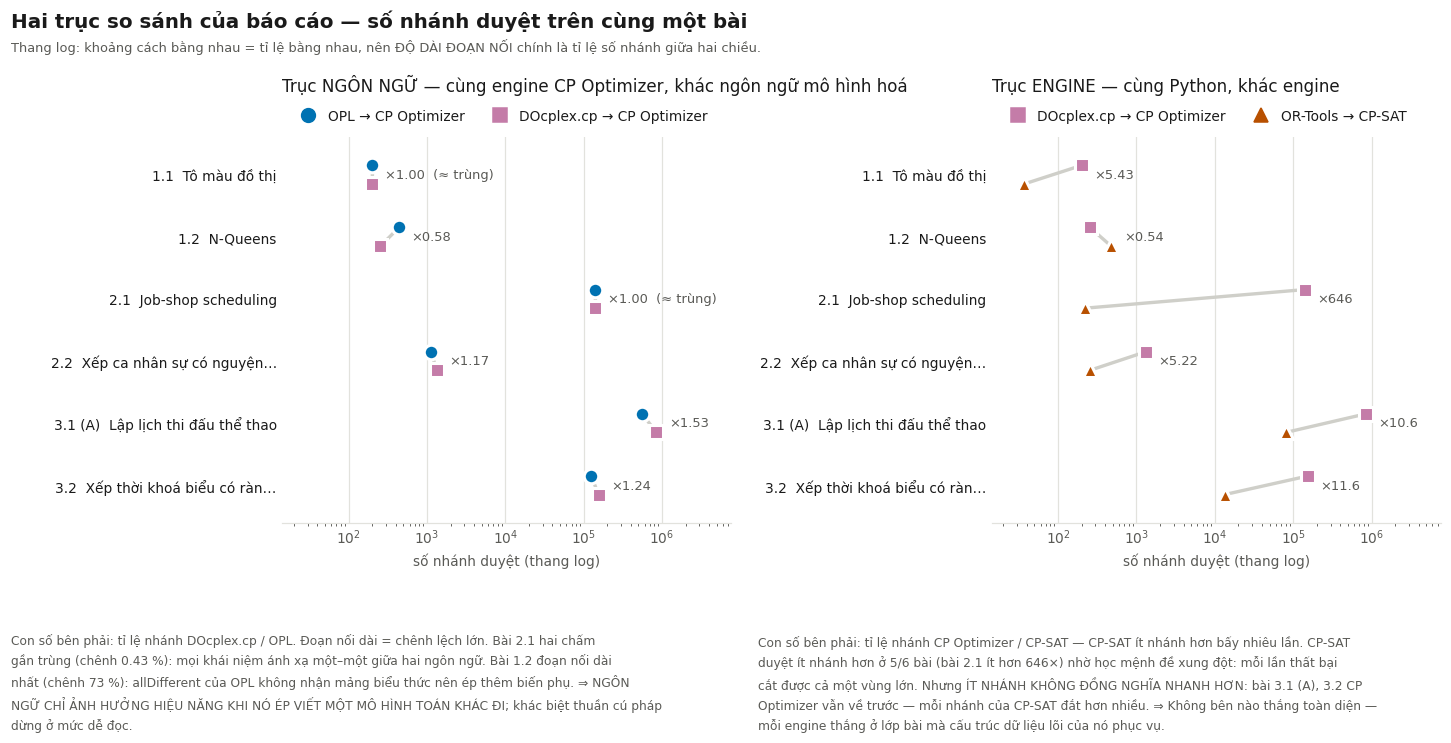

In [5]:
axis_charts(lang, eng)

## 4. Đối chiếu năng lực — cái gì có sẵn ở đâu

Bảng này tổng hợp từ những gì **thực sự gặp phải** khi cài đặt 6 bài, không phải
từ tài liệu quảng cáo. Mỗi dòng đều có một bài làm chứng.

| Khả năng | CP Optimizer | CP-SAT | Chứng cứ |
|---|---|---|---|
| `allDifferent` | ✅ | ✅ `add_all_different` | 1.1, 1.2, 3.1 |
| `allowedAssignments` (quan hệ bảng) | ✅ | ✅ `add_allowed_assignments` | 3.1 |
| `inverse` | ✅ | ✅ `add_inverse` — buộc miền `0..k-1` | 3.1 |
| `count` | ✅ | ❌ phải 1-hot, **+180 biến bool** ở $n=6$ | 3.1 |
| biến `interval`, `noOverlap` | ✅ | ✅ `new_interval_var`, `add_no_overlap` | 2.1, 3.2 |
| `alternative` — chọn tài nguyên, tự đồng bộ | ✅ | ❌ dựng tay literal hiện diện từng cặp | 3.2 |
| `forbidExtent` + hàm bậc thang — lịch bận | ✅ | ❌ bung thành phép tuyển, **1 bool mỗi (việc, thời điểm bận)** | 3.2 |
| dùng ràng buộc **như biểu thức** (reify tại chỗ) | ✅ | ❌ phải vật chất hoá qua biến trung gian | 3.1 |
| `exactly_one` / `at_most_one` ở tầng boolean | ❌ phải viết tổng số học | ✅ nguyên hàm, nạp thẳng thành CNF | 2.2 |
| `AddAutomaton`, `AddCircuit`, module routing | ❌ | ✅ | (ngoài phạm vi 6 bài) |

**Hai chiều thiếu hụt đối xứng nhau, và đó là lời giải thích cho toàn bộ trục engine:**

- Ở bài **3.2**, CP Optimizer có `alternative` và `forbidExtent` nên ràng buộc khả
  dụng **không sinh thêm một biến quyết định nào**; CP-SAT phải bù bằng biến bool.
  CP Optimizer thắng.
- Ở bài **2.2**, CP-SAT có `add_exactly_one` nạp thẳng thành mệnh đề CNF cho CDCL
  nên chứng minh tối ưu với **0 conflict**; `docplex.cp` không có tương đương ở
  tầng boolean, phải viết `sum(...) == 1` rồi lan truyền bằng suy luận khoảng, tốn
  418 fails. CP-SAT thắng.

⇒ Kết luận đúng **không phải** "engine nào mạnh hơn", mà là: **mỗi engine thắng ở
lớp bài mà cấu trúc dữ liệu lõi của nó phục vụ.** Và chỗ trống trong kho ví dụ
chính thức của mỗi bên chỉ về đúng cùng hướng đó.

## 5. Bài 3.2 — vì sao báo cáo cần đủ ba chiều

Đây là bài duy nhất có benchmark định lượng, và là bằng chứng rõ nhất cho luận
điểm phương pháp ở notebook mở đầu.

Nếu chỉ so hai chiều OPL và OR-Tools, số liệu nói **CP-SAT nhanh hơn 3.6×**:

| Chiều | Engine | Mã hoá | Thời gian |
|---|---|---|---|
| OPL | CP Optimizer | đếm có điều kiện | 8.60 s |
| OR-Tools | CP-SAT | interval | 2.42 s |

Kết luận đó **sai**. Thêm điểm đo thứ ba — cùng engine CP Optimizer nhưng dùng mã
hoá interval — thì bức tranh đảo ngược:

In [6]:
bench_table()

cấu hình,chiều,engine,mã hoá,lần chạy,mục tiêu,thời gian giải (s),nhánh,fails/conflicts
small,OPL,CP Optimizer,đếm có điều kiện,5,20,0.39,30412,12917
small,DOcplex.cp,CP Optimizer,interval,5,20,0.435,75025,33825
small,OR-Tools,CP-SAT,interval,5,20,0.0507,553,4
small+avail,OPL,CP Optimizer,đếm có điều kiện,5,21,0.47,45176,20250
small+avail,DOcplex.cp,CP Optimizer,interval,5,21,0.364,61824,26221
small+avail,OR-Tools,CP-SAT,interval,5,21,0.0613,549,4
large,OPL,CP Optimizer,đếm có điều kiện,5,44,17.938,216066,96460
large,DOcplex.cp,CP Optimizer,interval,5,44,0.666,34194,7037
large,OR-Tools,CP-SAT,interval,5,44,2.5243,15439,236
large+avail,OPL,CP Optimizer,đếm có điều kiện,5,47,8.596,125151,55086


Bảng trên đọc bằng `results/bench.csv` — file **do `make bench` sinh ra**, không nằm
trong kho. Trên một máy chưa chạy benchmark thì ô này in hướng dẫn chạy `make bench`
rồi đi tiếp, chứ không làm hỏng cả notebook.

Cùng số liệu đó vẽ thành hình:

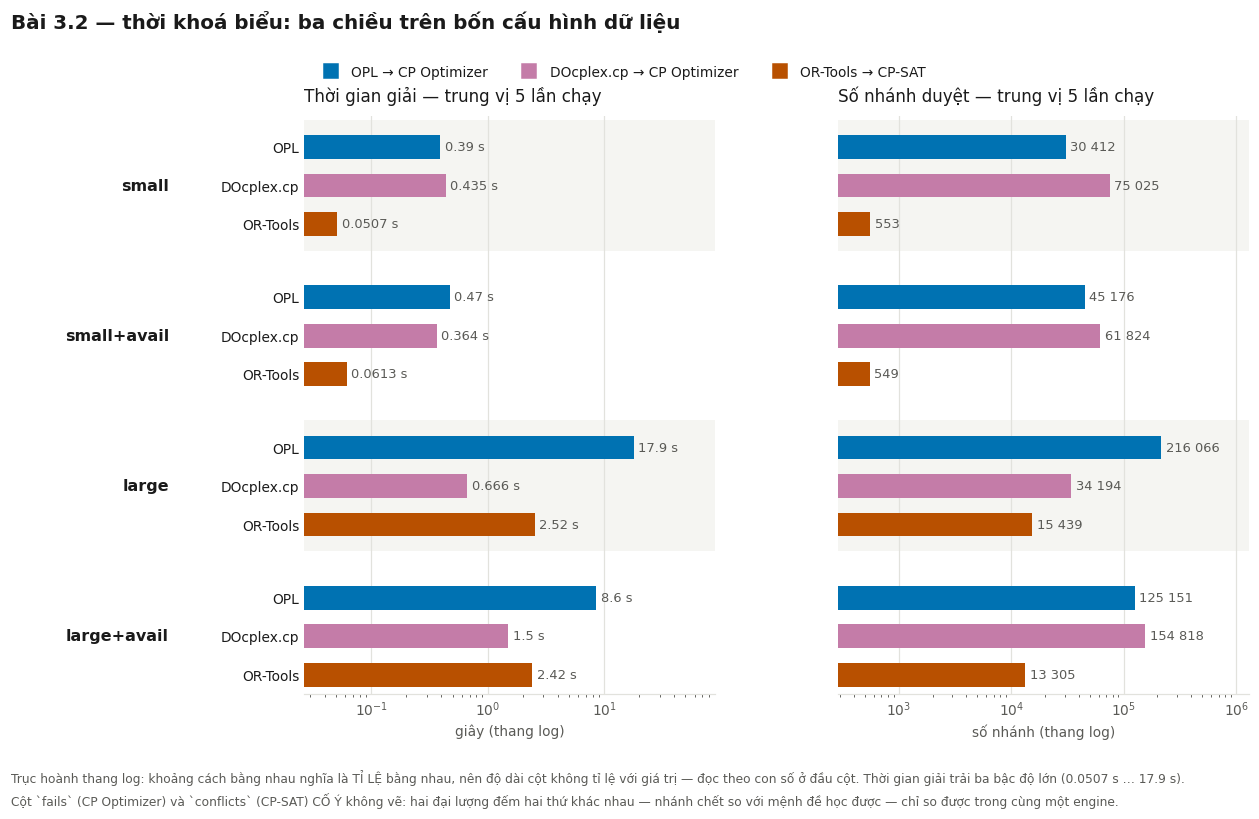

In [7]:
bench_chart()

Hình này là toàn bộ lập luận của mục 5 vẽ ra một lần. Đọc theo **hàng**, trong cùng
một cấu hình dữ liệu:

- Ở bộ `large` và `large+avail`, cột thời gian của **OPL dài hơn hẳn** hai cột kia,
  trong khi ở bộ `small` ba cột gần bằng nhau. Khoảng cách chỉ mở ra khi bài đủ lớn
  — đó là lý do bốn bài dưới 1 giây ở mục 3 không dùng để ngoại suy được.
- Đi từ **OPL sang DOcplex.cp** là đổi *cách mã hoá* mà giữ nguyên engine: ở bộ
  `large` thời gian tụt từ 17.9 s xuống 0.67 s. Đi tiếp sang **OR-Tools** là đổi
  *engine* mà giữ nguyên cách mã hoá: thời gian lại tăng lên 2.52 s. Phần lớn khoảng
  cách giữa OPL và OR-Tools là do **mã hoá**, không phải do engine.
- Hai panel không cùng một câu chuyện, và đó mới là điều đáng chú ý: ở `large`,
  OR-Tools duyệt **ít nhánh nhất** mà vẫn **chậm hơn** DOcplex.cp. Số nhánh và thời
  gian là hai đại lượng khác nhau — mỗi nhánh của CP-SAT đắt hơn nhiều.

Cột `fails`/`conflicts` cố ý không có mặt trên hình: hai engine đếm hai thứ khác
nhau, đặt cạnh nhau trên một trục là so hai thứ không so được.

Tách ra thành hai phép so, mỗi phép đổi **đúng một** biến số:

| Phép so | Đổi cái gì | Kết quả (bộ `large+avail`) |
|---|---|---|
| OPL → DOcplex.cp | **mã hoá** (đếm → interval), engine giữ nguyên | 8.60 s → 1.50 s, **nhanh 5.7×** |
| DOcplex.cp → OR-Tools | **engine** (CP Optimizer → CP-SAT), mã hoá giữ nguyên | 1.50 s → 2.42 s, **chậm 1.6×** |

Phần lớn khoảng cách 3.6× ban đầu đến từ **cách mã hoá**, không phải từ engine. Và
khi so công bằng trên cùng cách mã hoá thì **CP Optimizer mới là bên nhanh hơn** —
ngược hẳn kết luận rút ra từ hai chiều.

Đây chính là điều mà so sánh trực tiếp "OPL vs OR-Tools" không làm được, và là lý
do chiều DOcplex.cp tồn tại trong báo cáo này.

## 6. Trần Community Edition — đã đo được ở đâu

CP Optimizer bản Community chỉ nhận bài có không gian tìm kiếm tới $2^{1000}$.
Đây là giới hạn **giấy phép**, không phải giới hạn năng lực engine.

| Bài | log₂ không gian tìm kiếm | CP Optimizer | CP-SAT |
|---|---|---|---|
| 1.2 N-Queens, $N=8$ | 24.0 | ✅ | ✅ |
| 1.2 N-Queens, $N=200$ | ≈1529 | ❌ `FATAL[ENGINE_001]` | ✅ |
| 3.1 Sports, $n=6$ | 510.6 | ✅ | ✅ |
| 3.1 Sports, $n=8$ và $n=10$ | >1000 | ❌ `FATAL[ENGINE_001]` | ✅ giải tối ưu cả hai — **chỉ với `--workers 8`** |
| 3.2 Timetable, bộ `large` | 786.4 | ✅ | ✅ |
| 3.2 Timetable, `large` + khả dụng | **780.3** | ✅ | ✅ |

> ⚠️ **Hai ô CP-SAT ở hàng $n=8$ và $n=10$ chỉ đạt được nhờ `--workers 8`.** Ở cấu
> hình tái lập mặc định của kho (1 worker, seed cố định) thì 300 s **không đóng nổi**
> tối ưu: $n=8$ dừng ở `FEASIBLE` với objective 16 mà không chứng minh được, còn
> $n=10$ dừng ở objective **28**, còn xa nghiệm 16. Dùng 8 worker ở đúng chỗ này là
> hợp lý vì đây là phép đo **năng lực** — hỏi engine có dựng và giải nổi cỡ bài đó
> không — khác hẳn phép đo **so sánh** ở mục 3 và mục 5, vốn bắt buộc 1 worker để
> tái lập. Chi tiết ở `models/3.1_sports/NOTES.md` §d.4.

Ba điều rút ra:

1. **$n=10$ của bài 3.1 chính là cỡ dữ liệu trong bản gốc IBM** — bản Community
   không chạy nổi ví dụ chính thức của chính IBM. Muốn dùng đúng cỡ gốc thì cần
   license academic (miễn phí qua IBM Academic Initiative).
2. **Thêm ràng buộc làm không gian tìm kiếm GIẢM** (786.4 → 780.3 ở bài 3.2), dù
   số ràng buộc gần gấp đôi. Trần tính theo *không gian tìm kiếm*, không theo *số
   ràng buộc* — nên ràng buộc thực tế hơn không làm bài toán chạm trần sớm hơn.
3. **Cách mã hoá quyết định có lọt trần hay không.** Với mã hoá nhị phân,
   $\log_2$ không gian bằng đúng số biến bool; bài 3.2 mã hoá kiểu đó sẽ cần
   ~2800 và vượt trần, trong khi mã hoá bằng biến nguyên chỉ tốn 780.

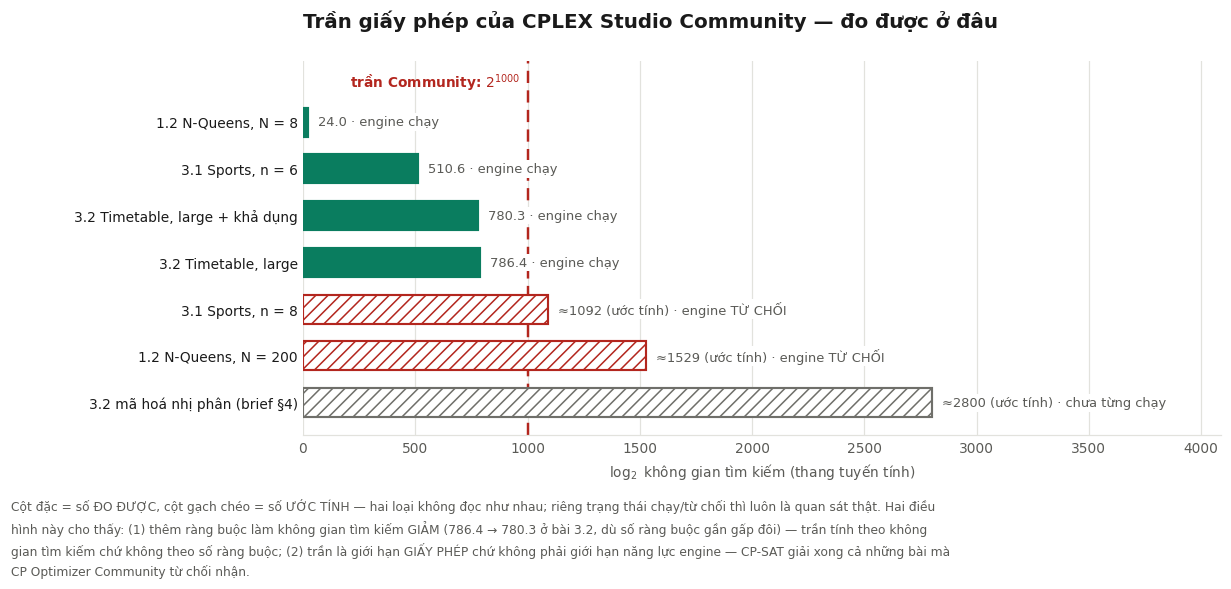

In [8]:
community_limit_chart()

Hình trên đặt bảng vừa rồi cạnh **một vạch duy nhất**: mốc $2^{1000}$. Nhìn theo
vạch đó thì thấy ngay ba điều mà cột số không nói ra được:

- **Mốc 1000 không cắt giữa "bài lớn" và "bài nhỏ" mà cắt giữa hai cách mã hoá.**
  Bài 3.2 với 449 biến nguyên chỉ dùng 780/1000, còn chính bài đó mã hoá nhị phân
  thì cần ~2800 — vượt trần gần ba lần. Cách mã hoá quyết định có lọt trần, không
  phải kích thước bài toán.
- **Hai cột 3.2 gần bằng nhau nhưng cột có thêm ràng buộc lại NGẮN HƠN** (780.3 so
  với 786.4), dù số ràng buộc gần gấp đôi. Trần tính theo không gian tìm kiếm chứ
  không theo số ràng buộc.
- **Cột đặc và cột gạch chéo phải đọc khác nhau.** Chỉ bốn cột đặc là số đo được;
  ba cột gạch chéo là ước tính kích thước. Riêng việc engine từ chối
  (`FATAL[ENGINE_001]`) thì luôn là quan sát thật, kể cả ở những cột ước tính.

## 7. Kết luận

**Về phương pháp.** Ba chiều là số tối thiểu để tách được nguyên nhân. Bài 3.2 cho
thấy so hai chiều dẫn tới kết luận ngược hẳn sự thật — và không có cách nào phát
hiện điều đó nếu chỉ nhìn hai cột số liệu.

**Về ngôn ngữ mô hình hoá.** Ngôn ngữ chỉ ảnh hưởng tới hiệu năng khi nó **ép viết
một mô hình toán khác đi**. Khác biệt thuần cú pháp dừng ở mức dễ đọc. OPL gọn hơn
ở ràng buộc quan hệ và tupleset; `docplex.cp` gọn hơn ở chỗ nhận thẳng biểu thức
Python vào ràng buộc toàn cục.

**Về engine.** Không có bên nào thắng toàn diện. CP-SAT thắng ở bài tổ hợp/boolean
nhờ học mệnh đề và các nguyên hàm boolean; CP Optimizer thắng ở bài lập lịch quy
mô lớn nhờ `alternative`, `forbidExtent` và bộ lan truyền chuyên cho biến interval.
Sáu bài của báo cáo cho 4–2 nghiêng về CP-SAT. Tỉ số này dựa trên **đo lặp nhiều
lần**, không phải trên một lần chạy: bảng tự sinh ở mục 3 quyết mỗi ô bằng đúng một
lần chạy nên nó ghi "≈ ngang nhau" ở bài 3.1, nơi chênh lệch nằm trong nhiễu của
đồng hồ. Bốn bài CP-SAT thắng đều giải xong dưới 1 giây; hai bài đủ lớn để thời
gian có ý nghĩa — 3.1 và 3.2 — thì CP Optimizer thắng cả hai.

**Về cách chọn công cụ.** Câu hỏi đúng không phải "engine nào tốt hơn" mà là *"bài
của tôi có cấu trúc gì"*:

| Nếu bài toán của bạn… | Nghiêng về |
|---|---|
| nhiều ràng buộc boolean, đếm, phủ, tổ hợp | **CP-SAT** |
| lập lịch có tài nguyên, lịch bận, chọn máy/người | **CP Optimizer** |
| cần routing, automaton, chuỗi trạng thái | **CP-SAT** (có sẵn `AddCircuit`, `AddAutomaton`) |
| cần chạy quy mô công nghiệp trên bản miễn phí | **CP-SAT** (không giới hạn giấy phép) |

**Một cảnh báo khi đọc lại báo cáo này.** Mọi số liệu đo trên **một máy, một bộ dữ
liệu, bản Community**. Chúng đủ để chỉ ra *cơ chế* — vì sao mã hoá này tốn nhiều
nhánh hơn, vì sao engine kia cần thêm biến phụ — nhưng không đủ để xếp hạng hiệu
năng tổng quát. Phần có giá trị lâu dài là các **cơ chế** đã truy được nguyên nhân
và kiểm chứng bằng thí nghiệm đối chứng, không phải các con số giây.